In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import warnings
warnings.filterwarnings(
  "ignore",
  message="Numcodecs codecs are not in the Zarr version 3 specification*",
  category=UserWarning
)

# setup all the imports
import matplotlib.font_manager
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  # noqa: E402
import numpy as np
import seaborn as sns
import pandas as pd
import xarray as xr

flist = matplotlib.font_manager.get_font_names()
from pathlib import Path  # noqa: E402

import extremeweatherbench as ewb

# make the basepath - change this to your local path
basepath = Path.home() / "extreme-weather-bench-paper" / ""
basepath = str(basepath) + "/"

import src.plots.plotting_utils as plot_utils  # noqa: E402
import src.plots.results_utils as results_utils  # noqa: E402
import src.plots.heat_freeze_utils as heat_freeze_utils  # noqa: E402
import src.plots.plotting_styles as ps  # noqa: E402

# load in all of the events in the yaml file
print("loading in the events yaml file")
ewb_cases = ewb.cases.load_ewb_events_yaml_into_case_list()

# build out all of the expected data to evalate the case
# this will not be a 1-1 mapping with ewb_cases because there are multiple data sources
# to evaluate for some cases
# for example, a heat/cold case will have both a case operator for ERA-5 data and GHCN
case_operators = ewb.cases.build_case_operators(
    ewb_cases, ewb.defaults.get_brightband_evaluation_objects()
)

loading in the events yaml file


In [24]:
# load in all the results
# heat results
hres_heat_results = pd.read_pickle(basepath + 'saved_data/hres_heat_results.pkl')
cira_fourv2_heat_results = pd.read_pickle(basepath + 'saved_data/cira_fourv2_heat_results.pkl')
cira_pangu_heat_results = pd.read_pickle(basepath + 'saved_data/cira_pangu_heat_results.pkl')
cira_graphcast_heat_results = pd.read_pickle(basepath + 'saved_data/cira_graphcast_heat_results.pkl')

# ar results
hres_ar_results = pd.read_pickle(basepath + 'saved_data/hres_ar_results.pkl')
cira_fourv2_ar_results = pd.read_pickle(basepath + 'saved_data/cira_fourv2_ar_results.pkl')
cira_pangu_ar_results = pd.read_pickle(basepath + 'saved_data/cira_pangu_ar_results.pkl')
cira_graphcast_ar_results = pd.read_pickle(basepath + 'saved_data/cira_graphcast_ar_results.pkl')


In [26]:
def get_error_array_for_heatmap(ewb_cases, results_array, hres_results, forecast_sources, 
    target_source, metric_strs, lead_time_days, higher_is_better_list):
    """
    This function takes in an array of results and parameters to say which results to grab and returns 
    error arrays and relative arrays for global, north america, and europe.
    """
    # now make the array for the scorecard
    global_rel_error = {}
    global_error = {}

    for i, metric in enumerate(metric_strs):
        # initialize the arrays
        global_rel_error[metric] = np.zeros((len(results_array), len(lead_time_days)))
        global_error[metric] = np.zeros((len(results_array), len(lead_time_days)))

        higher_is_better = higher_is_better_list[i]

        for j, results_df in enumerate(results_array):
            my_mean, my_relative_error = results_utils.compute_relative_error(ewb_cases, results_df, 
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source, 
                metric=metric, lead_time_days=lead_time_days, 
                higher_is_better=higher_is_better)
            global_error[metric][j, :] = my_mean
            global_rel_error[metric][j, :] = my_relative_error


    return global_error, global_rel_error

# setup for the scorecard
# Grab means for each metric for each model
heat_metric_str = ['MaximumMeanAbsoluteError', 'RootMeanSquaredError', 'MaximumLowestMeanAbsoluteError']
freeze_metric_str = ['MinimumMeanAbsoluteError', 'RootMeanSquaredError']
heat_display_str = ['MAE of Event High', 'RMSE', 'MAE of Event Low']
freeze_display_str = ['MAE of Event Low', 'RMSE']
heat_metric_higher_is_better = [False, False, False, False]

lead_time_days = [1, 3, 5, 7, 10]

heat_results_array = [hres_heat_results, cira_fourv2_heat_results, 
    cira_pangu_heat_results, cira_graphcast_heat_results]
heat_forecast_source = [ps.hres_ifs_settings['forecast_source'], 
    ps.cira_fourv2_gfs_settings['forecast_source'], ps.cira_pangu_gfs_settings['forecast_source'], 
    ps.cira_graphcast_gfs_settings['forecast_source']]

(global_heat_error, global_rel_heat_error) = \
    get_error_array_for_heatmap(ewb_cases, heat_results_array, hres_heat_results, 
    heat_forecast_source, 'ERA5', heat_metric_str, lead_time_days, heat_metric_higher_is_better )


# setup for the scorecard
# Grab means for each metric for each model
ar_metric_str = ['CriticalSuccessIndex', 'spatial_displacement']
ar_display_str = ['Critical Success Index', 'Spatial Displacement']
ar_metric_higher_is_better = [True, False, True]

lead_time_days = [1, 3, 5, 7, 10]

ar_results_array = [hres_ar_results, cira_fourv2_ar_results, 
    cira_pangu_ar_results, cira_graphcast_ar_results]
ar_forecast_source = [ps.hres_settings['forecast_source'], 
    ps.cira_fourv2_gfs_settings['forecast_source'], 
    ps.cira_pangu_gfs_settings['forecast_source'],
    ps.cira_graphcast_gfs_settings['forecast_source']]

(global_ar_error, global_rel_ar_error) = \
    get_error_array_for_heatmap(ewb_cases, ar_results_array, hres_ar_results, 
    ar_forecast_source, target_source='ERA5', metric_strs=ar_metric_str, 
    lead_time_days=lead_time_days, higher_is_better_list=ar_metric_higher_is_better )



In [27]:
# load ERA5 so we can plot individual cases
era5 = ewb.defaults.era5_heatwave_target.open_and_maybe_preprocess_data_from_source()
era5 = era5.rename({'time': 'valid_time'})
temp_climatology_ds = xr.open_zarr('gs://extremeweatherbench/datasets/surface_air_temperature_1990_2019_climatology.zarr/')
temp_climatology_ds = temp_climatology_ds.sel(quantile=0.85)

In [28]:
for case in ewb_cases:
    if case.event_type == 'heat_wave':
        print(case)


IndividualCase(case_id_number=1, title='2021 Pacific Northwest', start_date=datetime.datetime(2021, 6, 20, 0, 0), end_date=datetime.datetime(2021, 7, 3, 0, 0), location=BoundingBoxRegion(latitude_min=33.25, latitude_max=68.0, longitude_min=215.25, longitude_max=256.0), event_type='heat_wave')
IndividualCase(case_id_number=2, title='2022 Upper Midwest', start_date=datetime.datetime(2022, 5, 7, 0, 0), end_date=datetime.datetime(2022, 5, 17, 0, 0), location=BoundingBoxRegion(latitude_min=19.5, latitude_max=48.25, longitude_min=252.0, longitude_max=276.75), event_type='heat_wave')
IndividualCase(case_id_number=3, title='2022 California', start_date=datetime.datetime(2022, 6, 7, 0, 0), end_date=datetime.datetime(2022, 6, 15, 0, 0), location=BoundingBoxRegion(latitude_min=23.75, latitude_max=44.5, longitude_min=235.75, longitude_max=266.25), event_type='heat_wave')
IndividualCase(case_id_number=4, title='2022 Texas', start_date=datetime.datetime(2022, 6, 30, 0, 0), end_date=datetime.datetime

In [29]:
for case in ewb_cases:
    if case.case_id_number == 83:
        my_heat_case = case
        break
        print(case)


In [30]:
# plot our specific heat case
heatwave_dataset = heat_freeze_utils.generate_heatwave_dataset(era5, temp_climatology_ds, my_heat_case)
heat_freeze_utils.plot_heatwave_case(heatwave_dataset, my_heat_case, ax=axs[2, 0])

/home/amy/extreme-weather-bench-paper/.venv/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'ls'
  result = super().contour(*args, **kwargs)


(30, 12)
plotting the cases for each event type


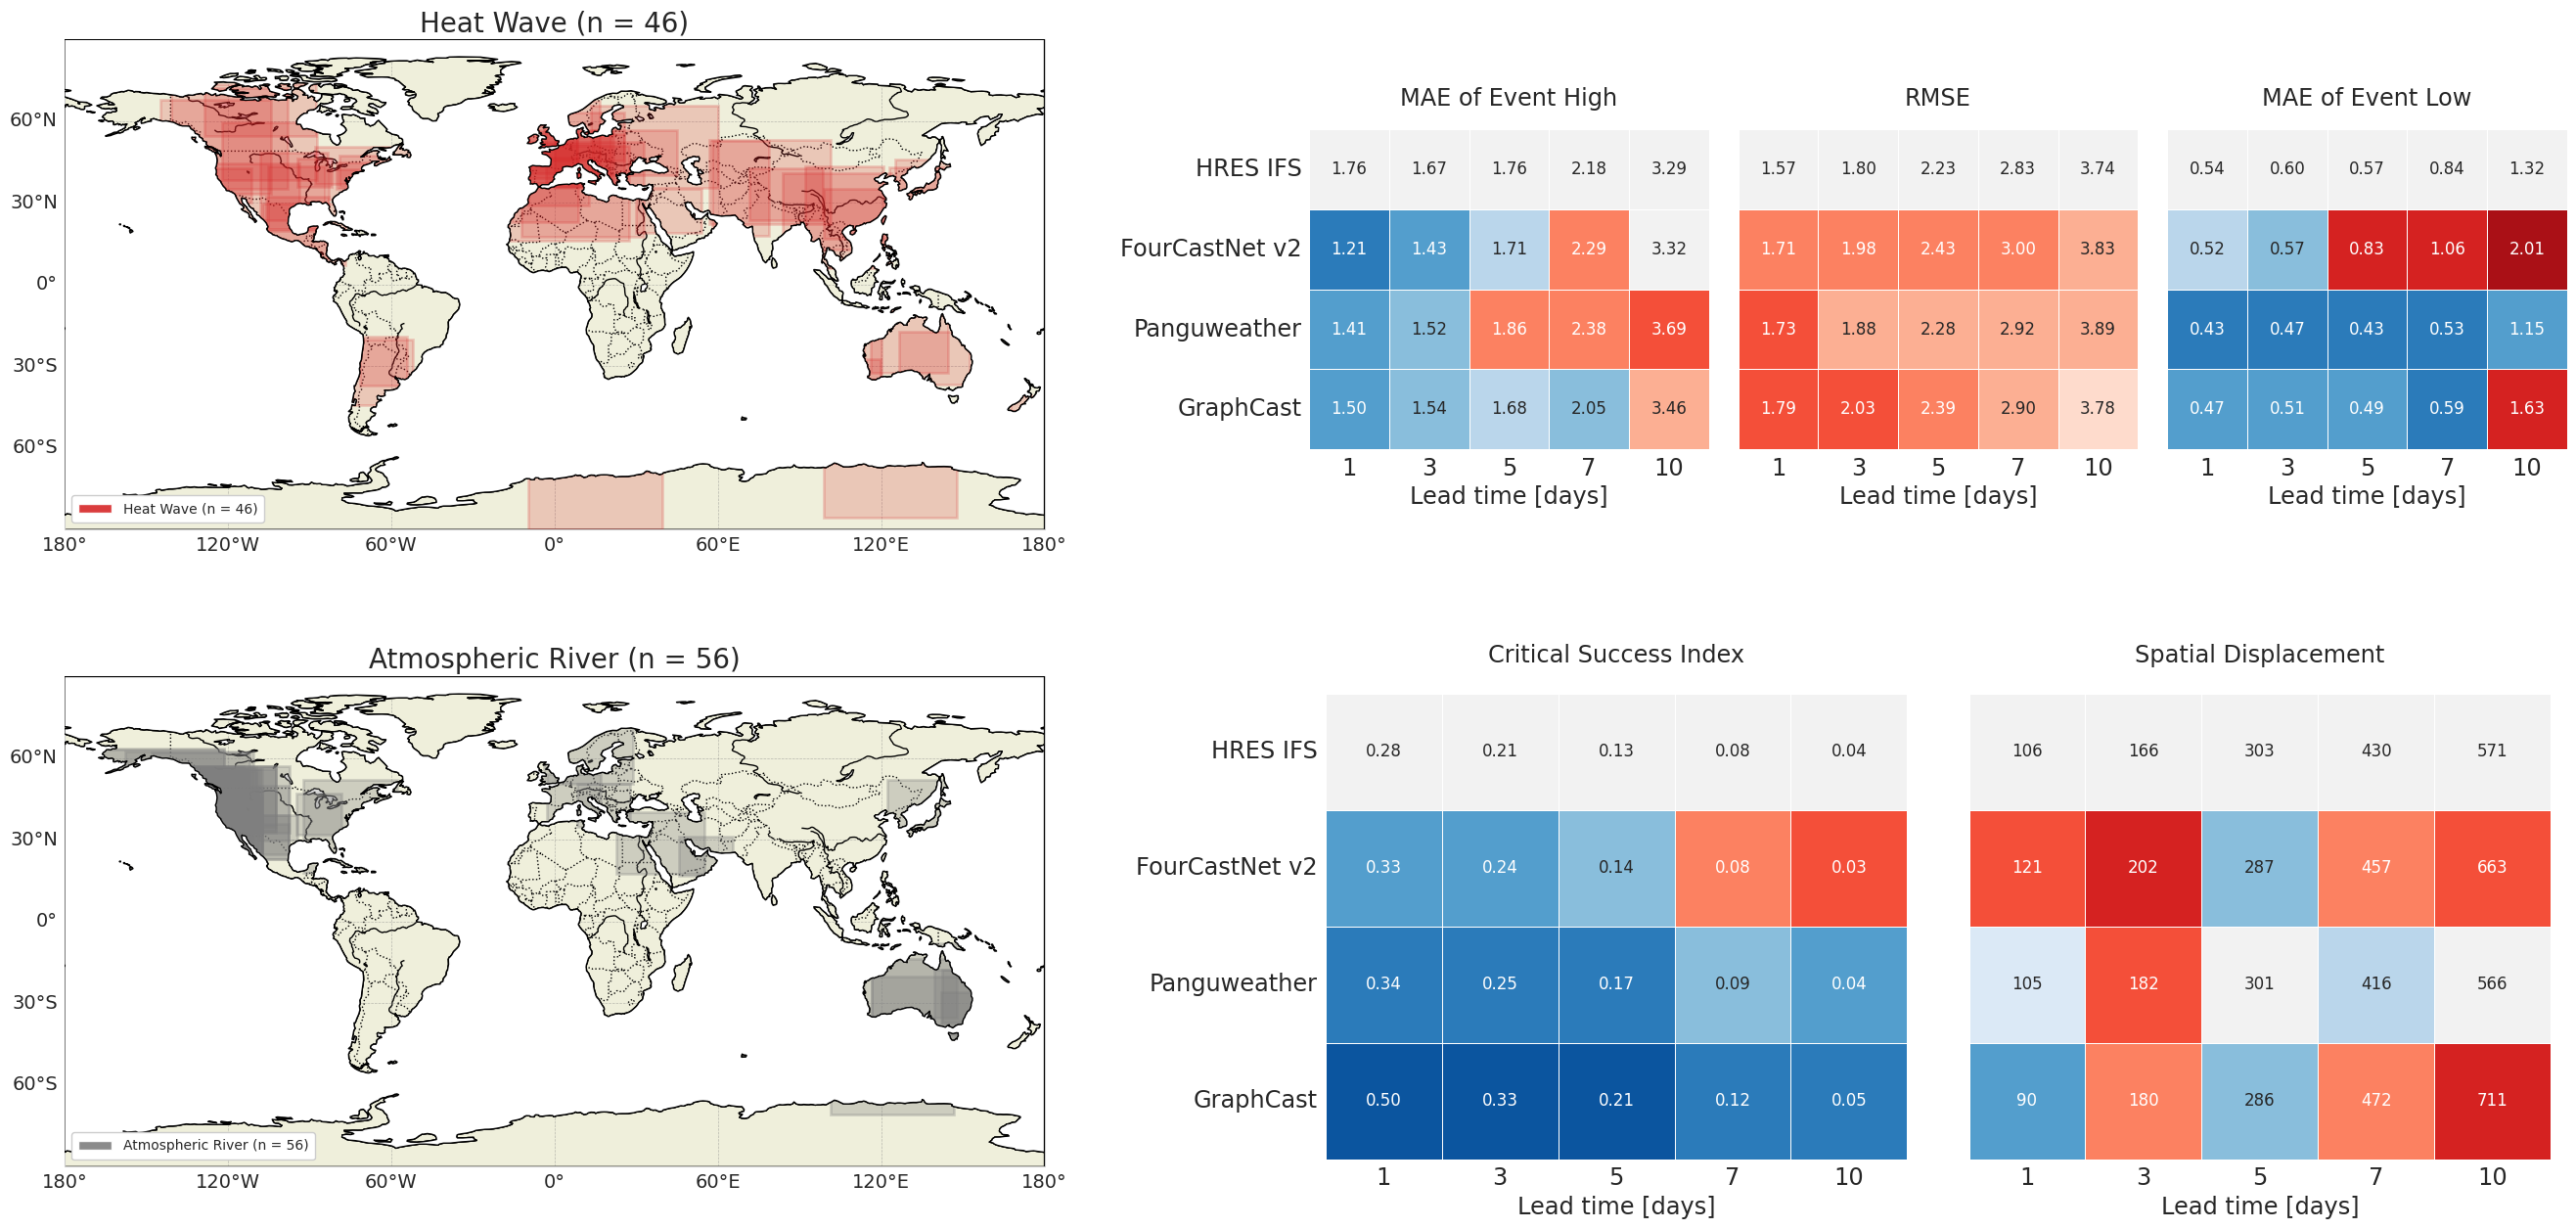

In [ ]:
from matplotlib.gridspec import GridSpec

n_rows = 3
n_cols = 2
figsize = (15 * n_cols, 6 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Use GridSpec for better control over subplot sizes, especially with mixed cartopy/regular subplots
# Make column 2 wider for line plots (width_ratios: col0, col1, col2)
# Use negative hspace to compress vertical spacing (negative values allow overlap)
gs = GridSpec(n_rows, n_cols, figure=fig, 
              left=0.05, right=0.95, top=0.98, bottom=0.02,
              wspace=0.1, hspace=0.3,  
              width_ratios=[1, 1])  # Make column 2 (index 2) 1.5x wider

# Create a grid of subplots - specify which ones should use cartopy
# Example: cartopy_subplots = [(0, 0), (1, 0)] means rows 0,1 in column 0 use cartopy
# You can modify this list to specify which subplots need cartopy projections
cartopy_subplots = [(0,0), (1,0)]  # Add tuples like (row, col) for subplots that need cartopy

# Create all subplots
axs = []
for i in range(n_rows):
    row = []
    for j in range(n_cols):
        if (i, j) in cartopy_subplots:
            # Create cartopy subplot
            ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        else:
            # Create regular matplotlib subplot
            ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axs.append(row)

# Convert to numpy array for easier indexing (matching plt.subplots behavior)
axs = np.array(axs)

# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="heat_wave",
    fill_boxes=True,
    ax=axs[0, 0],
)

# plot the specific heat case
# plot our specific heat case
heatwave_dataset = heat_freeze_utils.generate_heatwave_dataset(era5, temp_climatology_ds, my_heat_case)
heat_freeze_utils.plot_heatwave_case(heatwave_dataset, my_heat_case, ax=axs[1, 0])


plot_utils.plot_all_cases(
    ewb_cases,
    event_type="atmospheric_river",
    fill_boxes=True,
    ax=axs[2, 0],
)

heat_settings = {}
heat_settings["subplot_titles"] = heat_display_str
heat_settings["metric_str"] = heat_metric_str
heat_settings["lead_time_days"] = lead_time_days
heat_settings["model_order"] = ["HRES IFS", "FourCastNet v2", "Panguweather", "GraphCast"]


# second column of figure 2 shows the scorecard
plot_utils.plot_heatmap(
    global_rel_heat_error,
    global_heat_error,
    heat_settings,
    ax=axs[0, 1],
)

ar_settings = {}
ar_settings["subplot_titles"] = ar_display_str
ar_settings["metric_str"] = ar_metric_str
ar_settings["lead_time_days"] = lead_time_days
ar_settings["model_order"] = ["HRES IFS", "FourCastNet v2", "Panguweather", "GraphCast"]



plot_utils.plot_heatmap(
    global_rel_ar_error,
    global_ar_error,
    ar_settings,
    ax=axs[1, 1],
)
